<a href="https://colab.research.google.com/github/ti55987/DL4CM/blob/master/trnn_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Latent variable with continuous states extraction


In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

# import custom helper functions
!cp /content/gdrive/MyDrive/dl4rl/py_lib/prl_utils.py .
!cp "/content/gdrive/MyDrive/Colab Notebooks/latent/src/feature_utils.py" .
!cp "/content/gdrive/MyDrive/Colab Notebooks/latent/src/evaluation_utils.py" .

!nvidia-smi -L

Mounted at /content/gdrive
/bin/bash: line 1: nvidia-smi: command not found


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
from datetime import datetime

from numpy import sqrt
from numpy import argmax

from prl_utils import (
    Mode,
    normalize_train_labels,
    normalize_val_labels,
)

from feature_utils import (
    get_onehot_features,
    get_latent_labels,
)

from evaluation_utils import (
    plot_time_series,
    get_regression_rmse,
    add_corr_scores,
    get_all_agents_rmse,
    derive_rpe_from_q,
)

In [3]:
# @title Constants
N_TRAIN_AGENT = 3000
N_VAL_AGENT = 1000
NUM_TRIAL = 720
mode = Mode.HRL_NB6

if mode == Mode.PRL2:
  PARAM = '2ParamRL'
  result_dir = '2prl_rpe'
  feature_list = ['actions', 'rewards']
  data_subdir = ''
elif mode == Mode.PRL4:
  PARAM = '4ParamRL'
  result_dir = '4prl_rpe'
  feature_list = ['actions', 'rewards']
  data_subdir = 'prl_zou2022'
elif mode == Mode.HRL_NB6:
  data_subdir = 'hrl_li'
  result_dir = '/hrl_li'
  PARAM = 'HRL_counterfactual'

  train_file = f"{N_TRAIN_AGENT}agent_{NUM_TRIAL}t_{PARAM}.csv"
  test_file = f"{N_VAL_AGENT}agent_{NUM_TRIAL}t_{PARAM}.csv"

  num_bandits = 6
  feature_list = ['chosenside','rewards']
  for b in range(num_bandits):
    feature_list.append(f'allstims{b}')

  target_names = np.arange(num_bandits)
else:
  PARAM = 'HRL'
  result_dir = 'hrl_rpe'
  feature_list = ['chosenside','rewards', 'allstims0', 'allstims1', 'allstims2']
  data_subdir = ''

DRIVE_DIR = '/content/gdrive/MyDrive/Colab Notebooks/latent'
DATA_DIR = f'{DRIVE_DIR}/data/{data_subdir}' if len(data_subdir) > 0 else f'{DRIVE_DIR}/data'
RESULT_DIR = f"{DRIVE_DIR}/results/{result_dir}"

In [4]:
data = pd.read_csv(f'{DATA_DIR}/{train_file}')

data = data[data['agentid'] < N_TRAIN_AGENT]
features = get_onehot_features(data, feature_list)
features.shape

TensorShape([3000, 720, 30])

In [ ]:
n_agent = len(data['agentid'].unique())
n_trial = len(data['trials'].unique())

# Extract latent cue
chosen_cue_labels = get_latent_labels(data, ['chosencue'])
n_cue = len(data.chosencue.unique())
normalized_cue_labels = tf.keras.utils.to_categorical(chosen_cue_labels, num_classes=n_cue)
cue_output_dim = normalized_cue_labels.shape[-1]
# Extract parameters
name_to_labels = get_labels(data, Mode.HRL2)

In [ ]:
# @title split and shuffle data
from sklearn.model_selection import train_test_split

X_train, X_test, chosen_cue_train, chosen_cue_test, qv_train, qv_test = train_test_split(
    features.numpy(),
    normalized_cue_labels,
    train_labels,
    test_size=0.1,
    random_state=33,
)
print(
    X_train.shape,
    X_test.shape,
    chosen_cue_train.shape,
    chosen_cue_test.shape,
    qv_train.shape,
    qv_test.shape,
)

(2700, 720, 30) (300, 720, 30) (2700, 720, 6) (300, 720, 6) (2700, 720) (300, 720)


## Model Training

In [ ]:
# @title Model definition

from tensorflow.keras import layers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LSTM,
    Bidirectional,
    GRU,
    Concatenate,
)
from tensorflow import keras
from tensorflow.keras.optimizers import Adam, SGD

tf.keras.utils.set_random_seed(11)
tf.config.experimental.enable_op_determinism()

RNN = GRU
is_bidirection = True
op_loss = 'mse'

def create_gru_model(
    input_x: int, input_y: int, units: int=70, dropout: float=0.2, dropout1: float=0.2, dropout2: float=0.1, learning_rate: float=3e-4):
    activation_func = 'relu'

    encoder_inputs = layers.Input(shape=(None, features.shape[2]))
    encoder = Bidirectional(RNN(units, return_state=True, return_sequences=True))
    encoder_outputs, forward_h, backward_h = encoder(encoder_inputs)
    encoder_outputs = Dropout(dropout)(encoder_outputs) #Dropout(dropout)(encoder_outputs)

    # Dense layers
    outputs = Dense(int(units/2), activation='relu')(encoder_outputs)
    outputs = Dropout(dropout1)(outputs)
    outputs = Dense(int(units/4), activation='relu')(outputs)
    outputs = Dropout(dropout2)(outputs)
    outputs = Dense(output_dim, activation='linear')(outputs)

    best_model = keras.Model(encoder_inputs, outputs)

    optimizer = Adam(learning_rate=learning_rate)
    best_model.compile(loss=op_loss, optimizer=optimizer)
    return best_model

def create_multiple_loss_model(
    feature_dim: int,
    units: int = 70,
    dropout: float = 0.2,
    dropout1: float = 0.2,
    dropout2: float = 0.1,
    learning_rate: float = 3e-4,
):
    activation_func = "relu"
    # Bidirectional
    encoder_inputs = layers.Input(shape=(None, feature_dim))
    encoder = Bidirectional(RNN(units, return_state=True, return_sequences=True))
    encoder_outputs, forward_h, backward_h = encoder(encoder_inputs)
    encoder_outputs = Dropout(dropout)(encoder_outputs) #Dropout(dropout)(encoder_outputs)

    d_outputs_1 = Dense(int(units / 2), activation=activation_func)(encoder_outputs)
    d_outputs_1 = Dropout(dropout1)(d_outputs_1)
    d_outputs_1 = Dense(int(units / 4), activation=activation_func)(d_outputs_1)
    d_outputs_1 = Dropout(dropout2)(d_outputs_1)

    k_outputs = Dense(cue_output_dim, activation="softmax", name="chosen_cue")(d_outputs_1)
    # Dense layers
    linear_outputs = Dense(output_dim, activation="linear", name="q_values")(
        d_outputs_1
    )

    model = keras.Model(inputs=encoder_inputs, outputs=[k_outputs, linear_outputs])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        loss={
            "chosen_cue": "categorical_crossentropy",
            "q_values": "mse",
        },
        loss_weights={"chosen_cue": 0.2, "q_values": 1},
        optimizer=optimizer,
    )
    return model

def get_gru_model(parms):
    return create_gru_model(
        parms['input_x'], parms['input_y'], parms['units'], parms['dropout'], parms['dropout1'], parms['dropout2'], parms['learning_rate'])

output_dim

1

In [ ]:
batch_size = 128
units = 193 #
dropout = 0.07
dropout1 = 0.053
dropout2 = 0.014
learning_rate = 3e-4

prefix = 'chrl_nb6'
identifier = f'{prefix}_A{N_TRAIN_AGENT}_{n_trial}t_B{batch_size}_U{units}_{learning_rate}_D{dropout}_D{dropout1}_D{dropout2}'

best_model = create_multiple_loss_model(
    feature_dim=X_train.shape[-1],
    units=units,
    dropout=dropout,
    dropout1=dropout1,
    dropout2=dropout2,
    learning_rate=learning_rate,
)

# best_model = create_gru_model(
#     input_x=features.shape[1],
#     input_y=features.shape[2],
#     units=units,
#     dropout=dropout,
#     dropout1=dropout1,
#     dropout2=dropout2,
#     learning_rate=learning_rate)
identifier

'chrl_nb6_A3000_720t_B128_U193_0.0003_D0.07_D0.053_D0.014'

In [ ]:
callbacks = [EarlyStopping(monitor='val_loss', patience=35, restore_best_weights=True)]

history = best_model.fit(
    x=X_train,
    y={'chosen_cue': chosen_cue_train, 'q_values': qv_train},
    epochs=400,
    batch_size=batch_size,
    callbacks=callbacks,
    validation_data=(X_test, {'chosen_cue': chosen_cue_test, 'q_values': qv_test}),
    verbose=2,
)

# history = best_model.fit(
#   features,
#   y=train_labels,
#   batch_size=batch_size,
#   epochs=400,
#   verbose=2,
#   callbacks=callbacks,
#   validation_split=0.1,
# )

Epoch 1/400
22/22 - 14s - loss: 0.5597 - chosen_cue_loss: 1.8472 - q_values_loss: 0.1902 - val_loss: 0.4394 - val_chosen_cue_loss: 1.8263 - val_q_values_loss: 0.0741 - 14s/epoch - 629ms/step
Epoch 2/400
22/22 - 3s - loss: 0.4409 - chosen_cue_loss: 1.8133 - q_values_loss: 0.0783 - val_loss: 0.4259 - val_chosen_cue_loss: 1.8004 - val_q_values_loss: 0.0658 - 3s/epoch - 155ms/step
Epoch 3/400
22/22 - 3s - loss: 0.4288 - chosen_cue_loss: 1.7908 - q_values_loss: 0.0706 - val_loss: 0.4185 - val_chosen_cue_loss: 1.7779 - val_q_values_loss: 0.0629 - 3s/epoch - 155ms/step
Epoch 4/400
22/22 - 3s - loss: 0.4212 - chosen_cue_loss: 1.7673 - q_values_loss: 0.0678 - val_loss: 0.4125 - val_chosen_cue_loss: 1.7535 - val_q_values_loss: 0.0618 - 3s/epoch - 151ms/step
Epoch 5/400
22/22 - 3s - loss: 0.4161 - chosen_cue_loss: 1.7508 - q_values_loss: 0.0659 - val_loss: 0.4087 - val_chosen_cue_loss: 1.7424 - val_q_values_loss: 0.0603 - 3s/epoch - 150ms/step
Epoch 6/400
22/22 - 3s - loss: 0.4123 - chosen_cue_lo

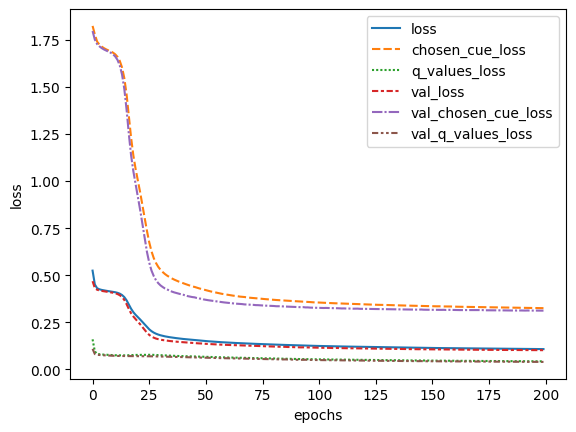

In [ ]:
result = pd.DataFrame(history.history)
ax = sns.lineplot(result)
ax.set_xlabel('epochs')
ax.set_ylabel('loss')

plt.savefig(f'{RESULT_DIR}/{identifier}.png')
best_model.save(f'{RESULT_DIR}/{identifier}_model')

## Model Evaluation

In [ ]:
# N_VAL_AGENT = 500
# NUM_TRIAL = 2000
test_data = pd.read_csv(f'{DATA_DIR}/{test_file}')
#test_data = test_data[test_data['trials'] < 1000]
test_features = get_onehot_features(test_data, feature_list)

if mode == Mode.HRL2:
  test_labels = _get_qv_labels(test_data)
  test_cue_labels = get_latent_labels(test_data, ['chosencue'])
  test_q_labels = _get_winning_q_labels(test_labels, test_cue_labels)
elif mode == Mode.HRL_NB6:
  test_labels = get_latent_labels(test_data, ['chosen_qv'])
  test_cue_labels = get_latent_labels(test_data, ['chosencue'])
else:
  #test_labels = test_data['rpe_history'].to_numpy().astype(np.float32).reshape((N_VAL_AGENT, n_trial))
  test_labels = _get_qv_labels(test_data, 2)

print(test_features.shape, test_labels.shape)

(1000, 720, 30) (1000, 720)


In [ ]:
#best_model = tf.keras.models.load_model(f'{RESULT_DIR}/qvc_A5000_2000t_B128_U193_0.0003_D0.07_D0.053_D0.014_model')
output_tokens = best_model.predict(test_features)

32/32 [==============================] - 2s 32ms/step


In [ ]:
# @title derive RPE

true_rpe = test_data['rpe_history'].to_numpy().reshape((N_VAL_AGENT, n_trial))
rewards = test_data['rewards'].to_numpy().astype(np.int64).reshape((N_VAL_AGENT, n_trial))
pred_rpe = []
if single_q_value:
  pred_rpe = rewards - output_tokens[1].reshape(N_VAL_AGENT, n_trial)
  pred_cue = np.argmax(output_tokens[0], axis=2)
else:
  pred_rpe = derive_rpe_from_q(test_data, output_tokens, True)

In [ ]:
df = pd.DataFrame({'true_rpe': true_rpe.ravel(), 'pred_rpe': pred_rpe.ravel() , 'pred_cue': pred_cue.ravel(), 'true_cue': test_data['chosencue'].ravel()})
df.to_csv(f'{RESULT_DIR}/{identifier}_rpe.csv')

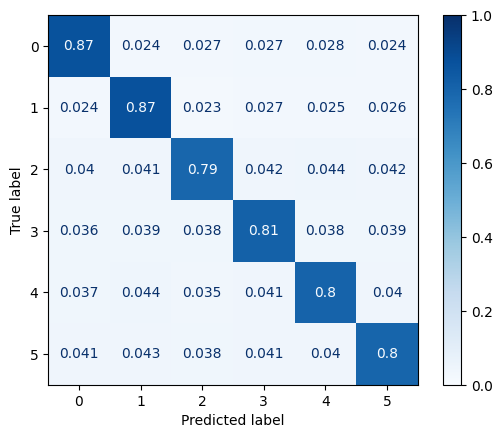

In [ ]:
# @title chosen cue confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    test_data['chosencue'].ravel(),
    pred_cue.ravel(),
    cmap=plt.cm.Blues,
    normalize='true')
# Set the fixed color bar range
disp.im_.set_clim(0, 1)

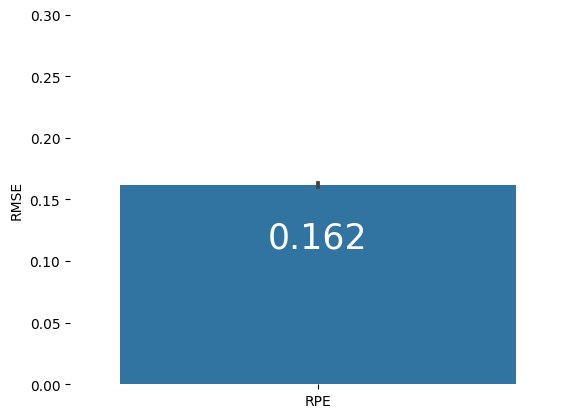

In [ ]:
# @title RMSE summary - bar plot

result = {'rmse': [], 'label': []}
if not single_q_value:
  pred_labels = output_tokens #[1]
  for i in range(test_labels.shape[-1]):
    true_labels = test_labels[:, :, i]
    y_pred = pred_labels[:, :, i]
    all_mse = get_all_agents_rmse(true_labels, y_pred, False)
    result['rmse'].extend(all_mse)
    result['label'].extend(len(all_mse)*[f'Q{i} value'])

all_mse = get_all_agents_rmse(true_rpe, pred_rpe, False)
result['rmse'].extend(all_mse)
result['label'].extend(len(all_mse)*['RPE'])

b = sns.barplot(result, x="label", y="rmse")
b.set_ylabel('RMSE')
b.set(ylim=(0, 0.3))

for i in b.containers:
    b.bar_label(i, fmt='%.3f', padding=-50, size=25, color='white')

sns.despine(bottom = True, left = True)

5.929583e-07 -0.097470045


Text(0.5, 1.0, 'RPE value')

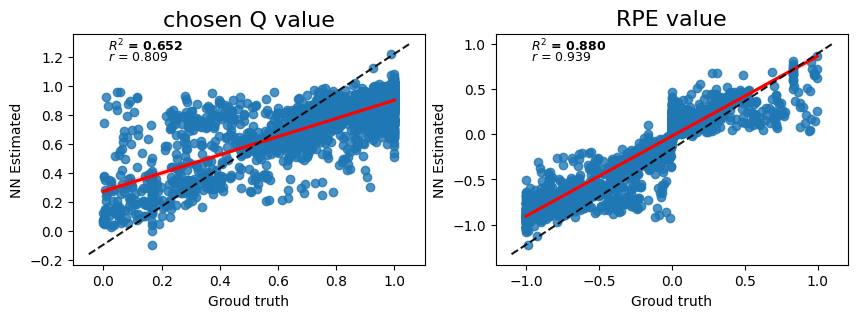

In [ ]:
# @title plot parameter recovery
from sklearn.metrics import r2_score

true_l, dl_l = 'Groud truth', 'NN Estimated'
ncols = 2
fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(ncols*5, 1*3), sharey=False, sharex=False)
pred_q = output_tokens[1].reshape(N_VAL_AGENT, n_trial)
# limit to 50 trials so it won't take too long
max_trial = 50
max_agent = 50

for i in range(1):
  true_labels = test_labels[:max_agent, :max_trial] if test_labels.ndim == 2 else test_labels[:max_agent, :max_trial, i]
  y_pred = pred_q[:max_agent, :max_trial] if test_labels.ndim == 2 else pred_q[:max_agent, :max_trial, i]

  result =  pd.DataFrame({true_l: true_labels.ravel(), dl_l: y_pred.ravel()})
  print(result[true_l].min(), result[dl_l].min())
  ax = sns.regplot(data=result, ci=99, x=true_l, y=dl_l, line_kws=dict(color="r"), ax=axes.flat[i])
  ax.plot(
      [ax.get_xlim()[0], ax.get_xlim()[1]],
      [ax.get_ylim()[0], ax.get_ylim()[1]],
      color="black",
      alpha=0.9,
      linestyle="dashed",
  )
  ax = add_corr_scores(ax, result[true_l], result[dl_l])

  ax.set_title('chosen Q value', fontsize=16)

result =  pd.DataFrame({true_l: true_rpe[:max_agent, :max_trial].ravel(), dl_l: pred_rpe[:max_agent, :max_trial].ravel()})
ax = sns.regplot(data=result, ci=99, x=true_l, y=dl_l, line_kws=dict(color="r"), ax=axes.flat[-1])
ax.plot(
    [ax.get_xlim()[0], ax.get_xlim()[1]],
    [ax.get_ylim()[0], ax.get_ylim()[1]],
    color="black",
    alpha=0.9,
    linestyle="dashed",
)
ax = add_corr_scores(ax, result[true_l], result[dl_l])

ax.set_title('RPE value', fontsize=16)

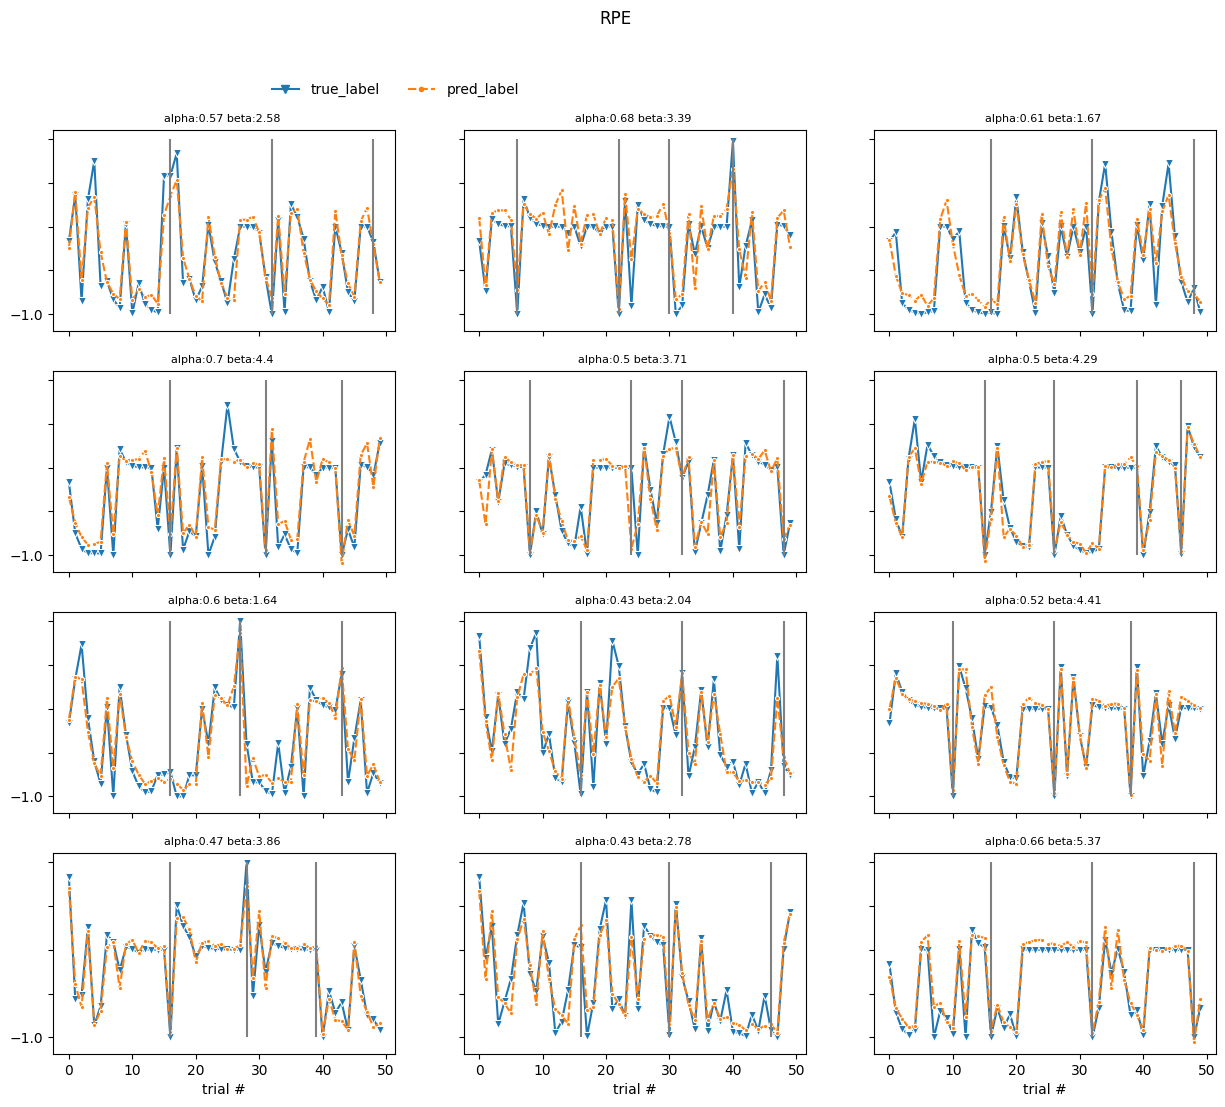

In [ ]:
# @title time series plot

import seaborn as sns
from prl_utils import get_labels

nrows = 4
fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(3*5, nrows*3), sharey=True, sharex=True)
fig.suptitle('RPE')

max_trial = 50
axes = plot_time_series(axes, true_rpe, pred_rpe, max_trial)

# add parameters to title and switch lines
name_to_labels = get_labels(test_data, Mode.HRL2)
isswitch = test_data[test_data.trials < max_trial]['isswitch']
isswitch = isswitch.to_numpy().astype(np.int64).reshape((N_VAL_AGENT, max_trial))
# correct_actions = test_data[test_data.trials < max_trial]['correct_actions']
# correct_actions = correct_actions.to_numpy().astype(np.int64).reshape((N_VAL_AGENT, max_trial))
for idx, ax in enumerate(axes.flat):
  title = ''
  for k, v in name_to_labels.items():
    val = round(v[idx][0], 2)
    title = f'{title}{k}:{val} '

  ax.set_title(title, size=8)
  #sns.lineplot(pd.Series(correct_actions[idx]), ax=ax, color='green', legend=False)
  switched_trials = np.argwhere(isswitch[idx])
  ax.vlines(x = switched_trials, ymin = -1, ymax = 1, color='grey')

#fig.tight_layout()

## Grid Search

In [ ]:
# For grid search
!pip install --upgrade keras-hypetune

In [ ]:
from kerashypetune import KerasBayesianSearch
from hyperopt import hp, Trials

model_func = get_gru_model
param_grid = {
  'input_x': features.shape[1],
  'input_y': features.shape[2],
  'units': 36 + hp.randint('units', 200),
  'learning_rate': 3e-4, #hp.loguniform('learning_rate', np.log(3e-4), np.log(3e-2)),
  'dropout': hp.uniform('dropout', .05, .25),
  'dropout1': hp.uniform('dropout1', .01, .1),
  'dropout2': hp.uniform('dropout2', .01, .05),
  'epochs': 25,
  'batch_size': 128,
}

kbs = KerasBayesianSearch(model_func, param_grid, monitor='val_loss', greater_is_better=False, n_iter=10, sampling_seed=11)
callbacks = [EarlyStopping(monitor='val_loss', patience=10)]
kbs.search(
    features,
    train_labels,
    trials=Trials(),
    validation_split=0.1,
    callbacks=callbacks)

print(kbs.best_params)
print(kbs.scores)